In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import mysql.connector
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Admin1234",
    database="olist_ecommerce"
)

print("✅ Connected to MySQL!")
print("✅ All libraries loaded!")

✅ Connected to MySQL!
✅ All libraries loaded!


In [2]:
# Load all 8 tables from MySQL into DataFrames
orders = pd.read_sql("SELECT * FROM orders", conn)
customers = pd.read_sql("SELECT * FROM customers", conn)
order_items = pd.read_sql("SELECT * FROM order_items", conn)
order_payments = pd.read_sql("SELECT * FROM order_payments", conn)
order_reviews = pd.read_sql("SELECT * FROM order_reviews", conn)
products = pd.read_sql("SELECT * FROM products", conn)
sellers = pd.read_sql("SELECT * FROM sellers", conn)

# Convert date columns
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print(f"✅ orders: {orders.shape}")
print(f"✅ customers: {customers.shape}")
print(f"✅ order_items: {order_items.shape}")
print(f"✅ order_payments: {order_payments.shape}")
print(f"✅ order_reviews: {order_reviews.shape}")
print(f"✅ products: {products.shape}")
print(f"✅ sellers: {sellers.shape}")

✅ orders: (99441, 8)
✅ customers: (99441, 5)
✅ order_items: (112650, 7)
✅ order_payments: (103886, 5)
✅ order_reviews: (99223, 7)
✅ products: (31087, 9)
✅ sellers: (3095, 4)


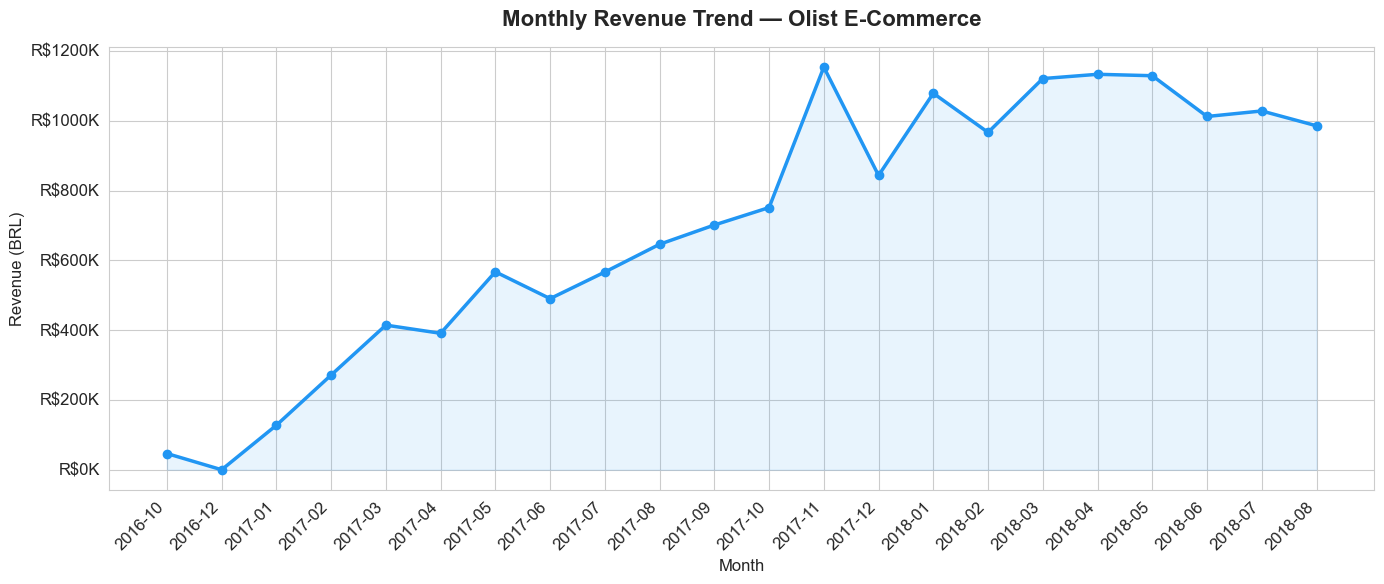

✅ Chart saved!


In [3]:
# Merge orders with payments
df = orders.merge(order_payments, on='order_id')
df = df[df['order_status'] == 'delivered']

# Monthly revenue
monthly = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum().reset_index()
monthly.columns = ['month', 'revenue']
monthly['month'] = monthly['month'].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly['month'], monthly['revenue'], marker='o', linewidth=2.5, color='#2196F3', markersize=6)
ax.fill_between(range(len(monthly)), monthly['revenue'], alpha=0.1, color='#2196F3')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['month'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
ax.set_title('Monthly Revenue Trend — Olist E-Commerce', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

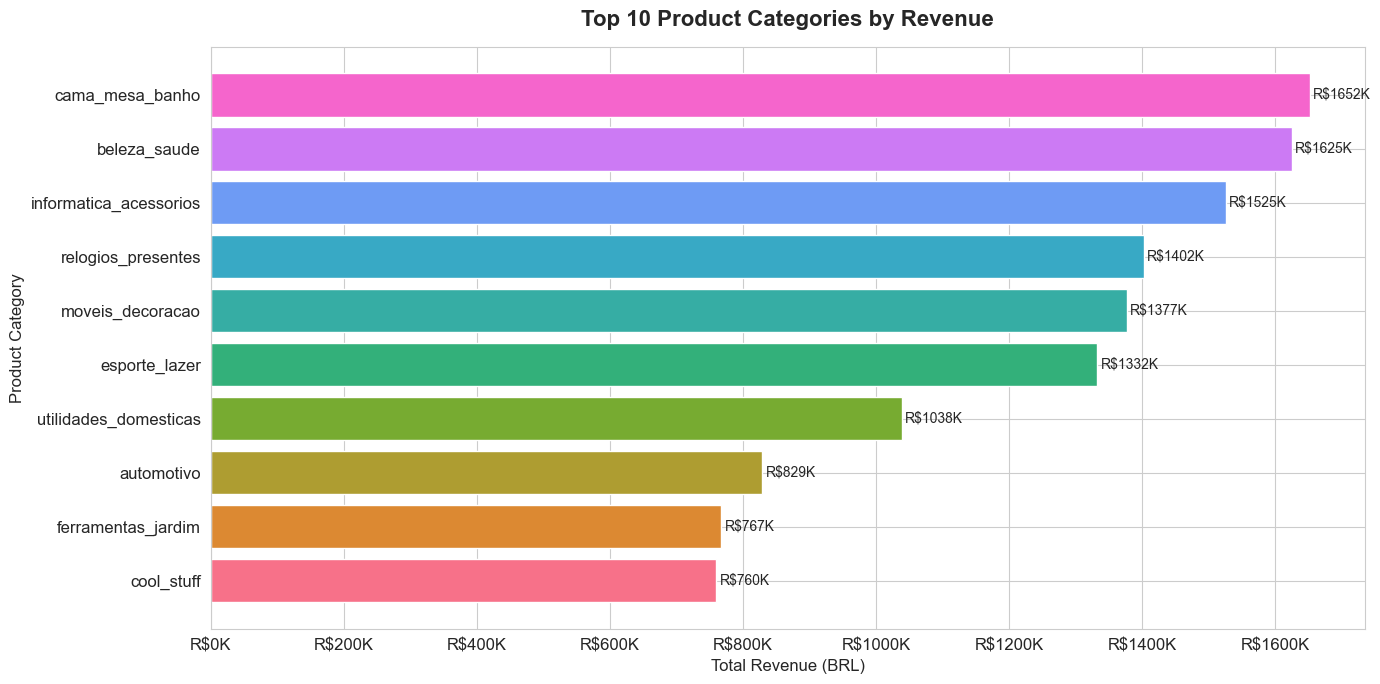

✅ Chart saved!


In [4]:
# Merge data
cat_df = order_items.merge(products[['product_id','product_category_name']], on='product_id')
cat_df = cat_df.merge(order_payments, on='order_id')

# Top 10 categories
top_cats = cat_df.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False).head(10)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1], color=sns.color_palette("husl", 10))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
for bar, val in zip(bars, top_cats.values[::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'R${val/1000:.0f}K', va='center', fontsize=10)
ax.set_title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Product Category')
plt.tight_layout()
plt.savefig('top_categories_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

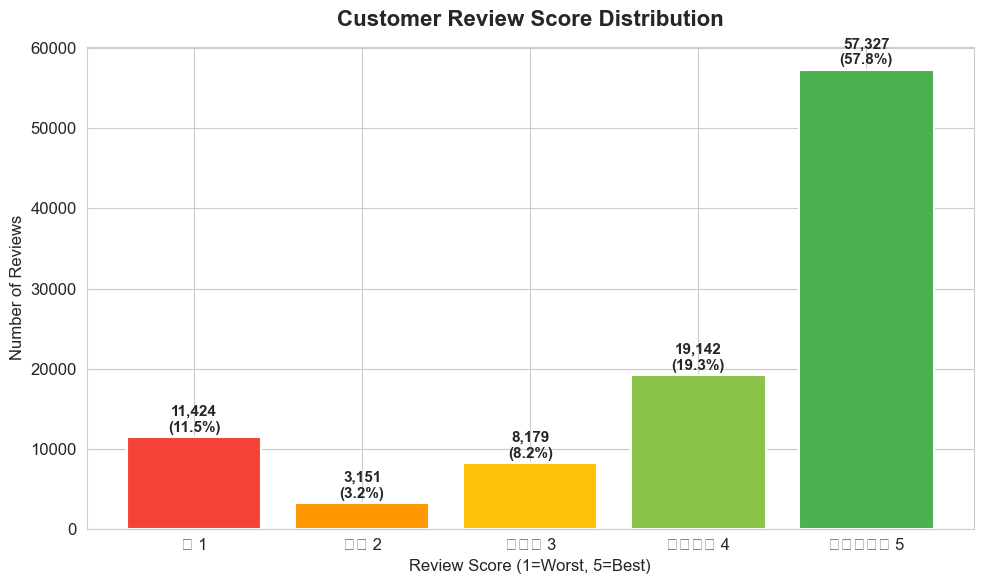

✅ Chart saved!


In [5]:
# Review score counts
review_counts = order_reviews['review_score'].value_counts().sort_index()

colors = ['#f44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(review_counts.index, review_counts.values, color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, review_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}\n({val/len(order_reviews)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Customer Review Score Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Review Score (1=Worst, 5=Best)')
ax.set_ylabel('Number of Reviews')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['⭐ 1', '⭐⭐ 2', '⭐⭐⭐ 3', '⭐⭐⭐⭐ 4', '⭐⭐⭐⭐⭐ 5'])
plt.tight_layout()
plt.savefig('review_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

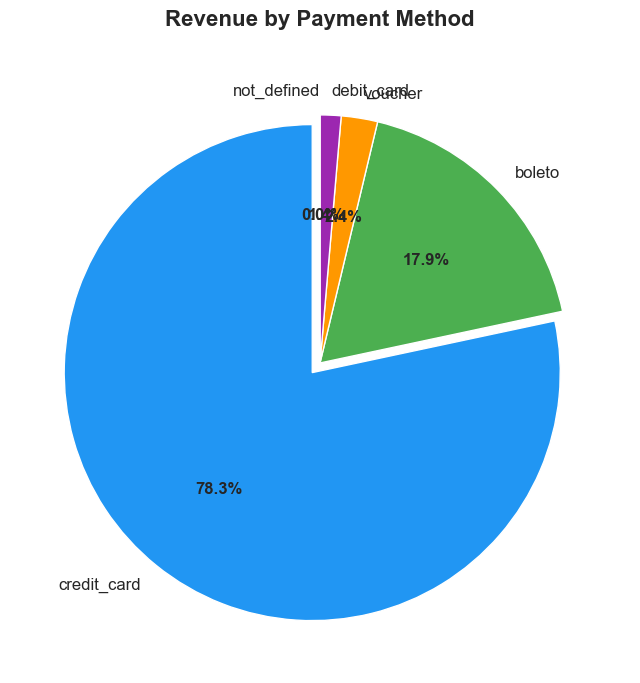

✅ Chart saved!


In [6]:
# Payment type revenue
pay_df = order_payments.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#f44336']
explode = (0.05, 0, 0, 0, 0)

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    pay_df.values,
    labels=pay_df.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12}
)
for text in autotexts:
    text.set_fontweight('bold')

ax.set_title('Revenue by Payment Method', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('payment_method_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

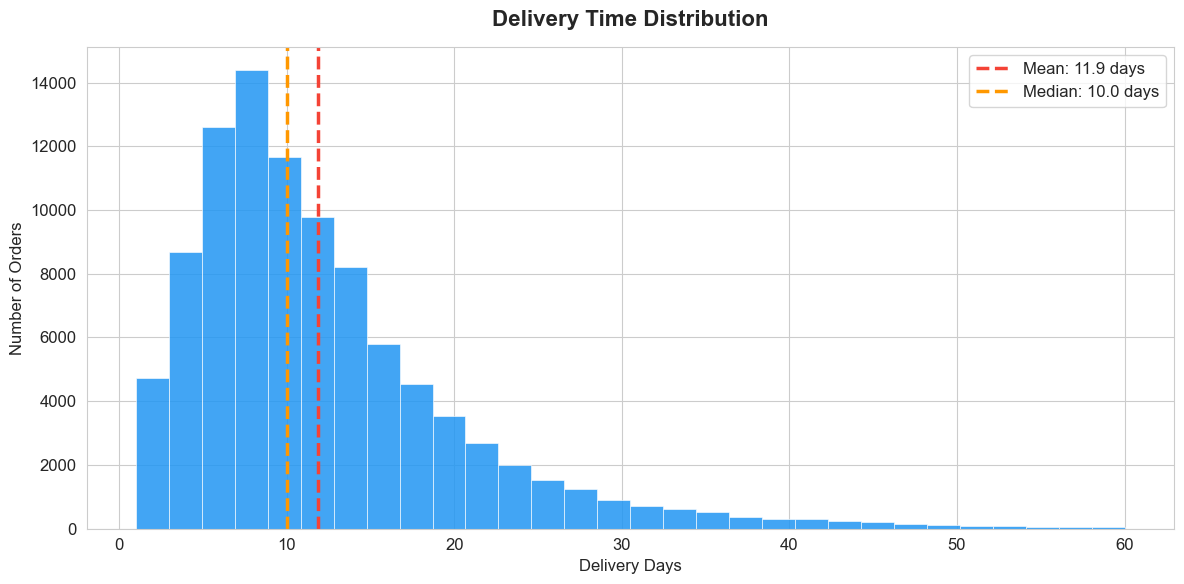

✅ Chart saved!


In [7]:
# Calculate delivery days
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - 
                               delivered['order_purchase_timestamp']).dt.days
delivered = delivered[delivered['delivery_days'].between(1, 60)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(delivered['delivery_days'], bins=30, color='#2196F3', 
        edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(delivered['delivery_days'].mean(), color='#f44336', 
           linewidth=2.5, linestyle='--', label=f"Mean: {delivered['delivery_days'].mean():.1f} days")
ax.axvline(delivered['delivery_days'].median(), color='#FF9800', 
           linewidth=2.5, linestyle='--', label=f"Median: {delivered['delivery_days'].median():.1f} days")
ax.set_title('Delivery Time Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Delivery Days')
ax.set_ylabel('Number of Orders')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('delivery_days_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

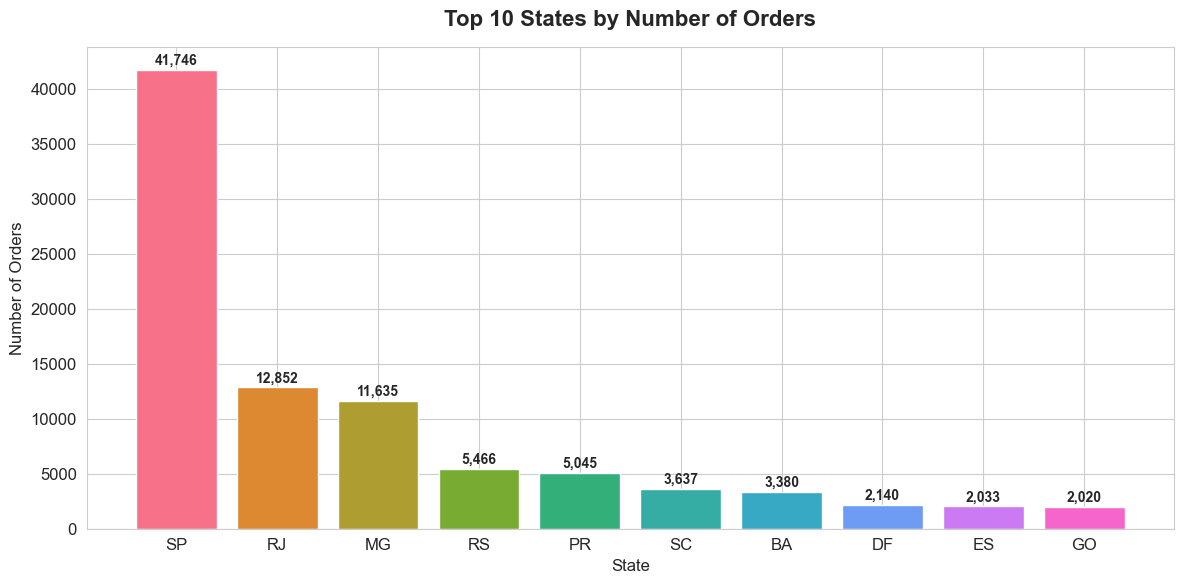

✅ Chart saved!


In [8]:
# Merge orders with customers
state_df = orders.merge(customers, on='customer_id')
state_orders = state_df.groupby('customer_state')['order_id'].count().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(state_orders.index, state_orders.values, 
              color=sns.color_palette("husl", 10), edgecolor='white')

for bar, val in zip(bars, state_orders.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Top 10 States by Number of Orders', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('State')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('orders_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

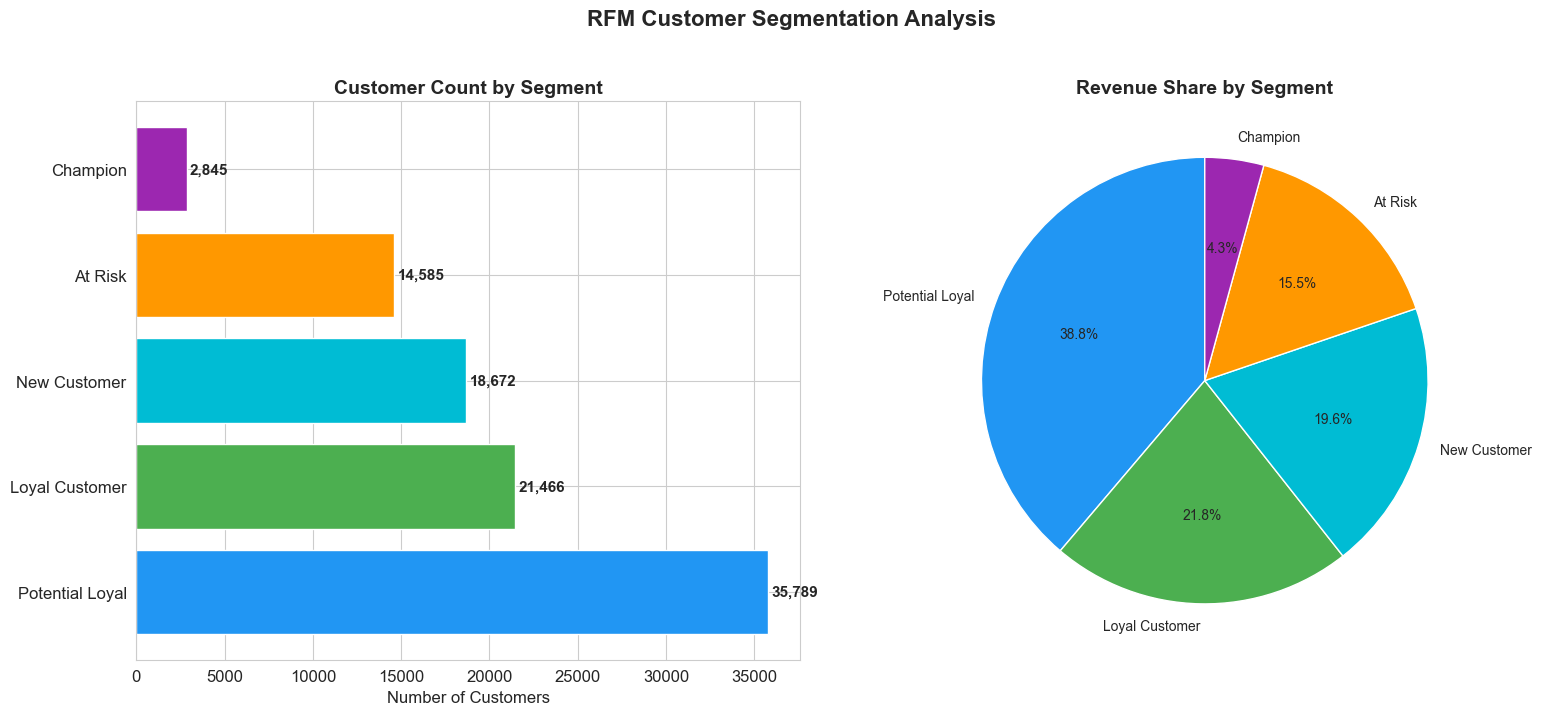

✅ Chart saved!


In [9]:
# RFM segment data from our Day 3 analysis
segments = ['Potential Loyal', 'Loyal Customer', 'New Customer', 'At Risk', 'Champion']
counts = [35789, 21466, 18672, 14585, 2845]
colors = ['#2196F3', '#4CAF50', '#00BCD4', '#FF9800', '#9C27B0']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart
bars = ax1.barh(segments, counts, color=colors, edgecolor='white')
for bar, val in zip(bars, counts):
    ax1.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=11, fontweight='bold')
ax1.set_title('Customer Count by Segment', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Customers')

# Pie chart
revenue = [5983300, 3365936, 3024480, 2391387, 657355]
ax2.pie(revenue, labels=segments, autopct='%1.1f%%', colors=colors,
        startangle=90, textprops={'fontsize': 10})
ax2.set_title('Revenue Share by Segment', fontsize=14, fontweight='bold')

plt.suptitle('RFM Customer Segmentation Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

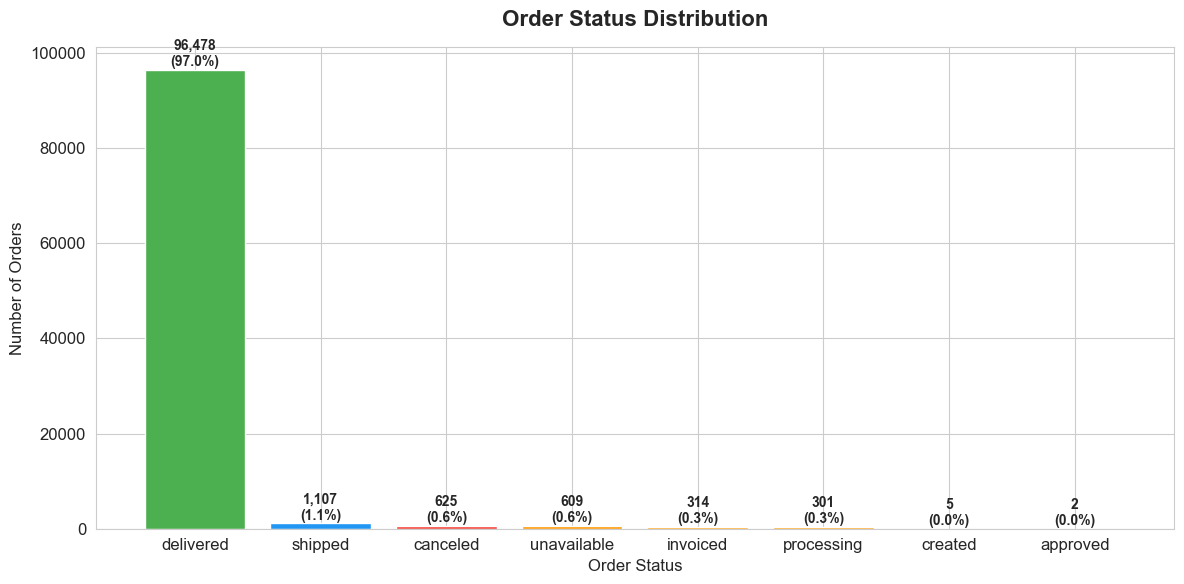

✅ Chart saved!


In [10]:
# Order status
status_counts = orders['order_status'].value_counts()

colors = ['#4CAF50' if s == 'delivered' else '#2196F3' if s == 'shipped' 
          else '#f44336' if s == 'canceled' else '#FF9800' 
          for s in status_counts.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(status_counts.index, status_counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, status_counts.values):
    pct = val / len(orders) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Order Status Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Order Status')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('order_status_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [11]:
import os

# Create export folder
export_path = r"C:\Users\Ranvijay\OneDrive\Desktop\olist_powerbi"
os.makedirs(export_path, exist_ok=True)

# Export all tables as clean CSVs
orders.to_csv(f"{export_path}/orders.csv", index=False)
customers.to_csv(f"{export_path}/customers.csv", index=False)
order_items.to_csv(f"{export_path}/order_items.csv", index=False)
order_payments.to_csv(f"{export_path}/order_payments.csv", index=False)
order_reviews.to_csv(f"{export_path}/order_reviews.csv", index=False)
products.to_csv(f"{export_path}/products.csv", index=False)
sellers.to_csv(f"{export_path}/sellers.csv", index=False)

# Export monthly revenue summary
monthly_export = orders[orders['order_status']=='delivered'].merge(order_payments, on='order_id')
monthly_summary = monthly_export.groupby(
    monthly_export['order_purchase_timestamp'].dt.to_period('M')
)['payment_value'].sum().reset_index()
monthly_summary.columns = ['month', 'revenue']
monthly_summary['month'] = monthly_summary['month'].astype(str)
monthly_summary.to_csv(f"{export_path}/monthly_revenue.csv", index=False)

print(f"✅ All CSVs exported to: {export_path}")
print(f"✅ orders.csv — {len(orders):,} rows")
print(f"✅ customers.csv — {len(customers):,} rows")
print(f"✅ order_items.csv — {len(order_items):,} rows")
print(f"✅ order_payments.csv — {len(order_payments):,} rows")
print(f"✅ order_reviews.csv — {len(order_reviews):,} rows")
print(f"✅ products.csv — {len(products):,} rows")
print(f"✅ sellers.csv — {len(sellers):,} rows")
print(f"✅ monthly_revenue.csv — {len(monthly_summary):,} rows")
print("\n🎉 Day 5 Complete! Ready for Power BI!")

✅ All CSVs exported to: C:\Users\Ranvijay\OneDrive\Desktop\olist_powerbi
✅ orders.csv — 99,441 rows
✅ customers.csv — 99,441 rows
✅ order_items.csv — 112,650 rows
✅ order_payments.csv — 103,886 rows
✅ order_reviews.csv — 99,223 rows
✅ products.csv — 31,087 rows
✅ sellers.csv — 3,095 rows
✅ monthly_revenue.csv — 22 rows

🎉 Day 5 Complete! Ready for Power BI!
